## Praos transaction progression model

1. [Model overview](#mo)
2. [Extensions, Imports and Uitlity Functions](#eiuf)
3. [Primitive outcomes, Parameters and DeltaQSD model](#popdm)
4. [Results](#results)

### Model overview <a name="mo"></a>

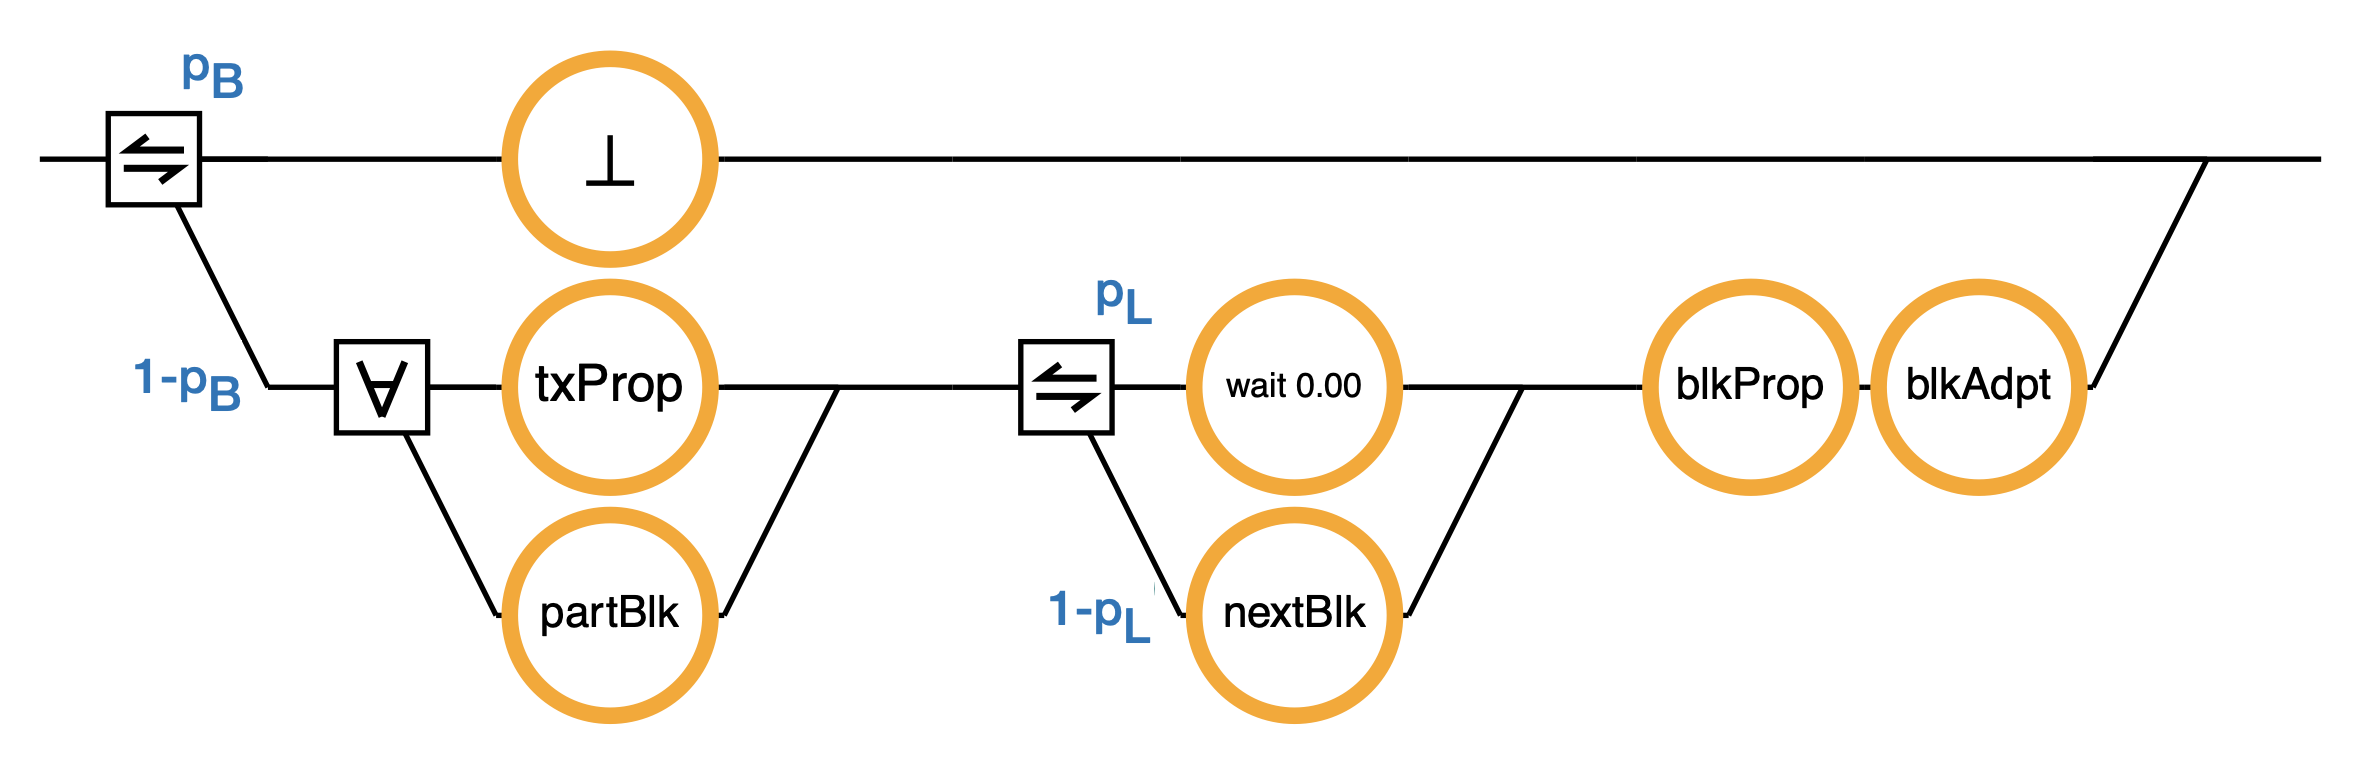

#### Model description

This model uses two choices based on load:
* whether a submitted tx is rejected because of a full mempool at the node where it is submitted
* whether an accepted tx is in the lower or upper part of a mempool

Once a node is submitted, two things need to happen before it can appear in a block:
* it has to be propogated to the node that produces the next block
* the next block has to be produced

After that, the choice is about a transaction being placed in the first block forged (if it is in the lower half og the mempool) or the second block forged (if it is in the upper half of the mempool).

#### Data sources

* Choice probabilities: Markovian or semi-Markovian bulk service models (load dependent)
* CDF for nextBlk: canary transaction that immediately placed in a block (load independent)
* CDF for txPrpg: BB's work on transaction propogation combined with PT's hop model (load independent)
* CDF for fullBlock: exponential distribution with rate 0.05 (active slot fraction)
* CDF for blkPrpg and blkAdpt: CF daily data (plus an argument this is not load dependent)


### Extensions, Imports and Utility functions <a name="eiuf"></a>

In [13]:
-- Extensions

--{-# LANGUAGE TypeFamilies #-}
--{-# LANGUAGE FlexibleContexts #-}

-- Imports

import Numeric
import DeltaQ
import Graphics.Rendering.Chart
import Graphics.Rendering.Chart.Backend.Cairo

import Data.Maybe (fromMaybe)


In [14]:
-- Utility Functions

-- *** Create a DQ function to represent a CDF from a list ***

   -- check that delays are monotonically increasing 

checkDataOrder :: [(Rational, Rational)] -> [(Rational, Rational)]
checkDataOrder ((p1,x1):(p2,x2):xs) = if x1<=x2
                            then (p1,x1) : checkDataOrder ((p2,x2) : xs )
                            else error "delays are not monotonically increasing"
checkDataOrder x = x

    -- construct a DQ expression from list of probability-value pairs
    -- based on code written by Peter Thompsom

measuredDQ :: [(Rational, Rational)]  -- ordered list of delays 
           -> DQ                      -- the delay distribution
-- we have a list of (probability, delay), ordered on the delays
measuredDQ delays = choices dataPoints
  where
    -- we add a (0, 0) point at the beginning to ensure that the first delay is always 0
    extendedData = checkDataOrder $ if head delays == (0, 0) then delays else (0, 0) : delays 
    -- the weight of each point is the difference in probability
    dataPoints = 
      [(p' - p, delayComponent d' d) | 
       ((p, d), (p', d')) <- zip extendedData (tail extendedData)]
    -- if we have two delays with the same percentage probability, we 
    -- simply wait for that time
    -- otherwise we use a uniform distribution between the two delays
    delayComponent d1 d2 = if d1 == d2 then wait d1 else uniform d1 d2
    -- input checking

-- *** Functions to create lists for use with measuredDQ ***

   -- for a list of values and a function, create a list of pairs
   -- calulating the y value from each value and returning the pair
   -- y value first

probList :: [Rational]
         -> (Rational -> Rational)
         -> [(Rational,Rational)]
probList l f = map (\x -> (f x, x)) l

   -- make a list starting at zero with the specfied step size
   -- and endpoint

makeList :: Rational
         -> Rational
         -> [Rational]
makeList step stop = [0.0,step..stop]

   -- calculate a valuefrom the exponential CDF

expCDF :: Double
       -> Rational
       -> Rational
expCDF r x = toRational $ 1 - exp ( -r * fromRational x)


### Primitive outcomes, Parameters and DeltaQSD model <a name="popdm"></a>

In [15]:
-- Cardano active slot fraction

activeFraction = 0.05

-- approximate an exponential distribution with rate that is the active slot fraction

nextBlock :: DQ
nextBlock = measuredDQ $ probList (makeList 10 100) $ expCDF activeFraction

-- from canary txs that go into first available block
-- https://github.com/input-output-hk/ouroboros-leios/blob/main/analysis/canary/ReadMe.ipynb
-- for the period 2024-12-01 to 2025-10-31

ct_B1 = [(0.0,0.0),(0.1,3.0),(0.2,5.0),(0.3,8.0),(0.4,11.0),(0.5,14.0),(0.6,19.0),(0.7,24.0),(0.8,32.0),(0.9,46.0),(0.9,46.0),(0.91,48.0),(0.92,50.0),(0.93,53.0),(0.94,56.0),(0.95,60.0),(0.96,64.0),(0.97,70.0),(0.98,77.0),(0.99,91.0),(1.0,203.0)]

partBlock :: DQ
partBlock = measuredDQ ct_B1

-- from CF daily data, working with 95%, given in milliseconds
-- https://data.blockperf.cardanofoundation.org/daily/index.html
-- for the period 2024-12-01 to 2025-10-31

all_dPP95 = map (\(x,y) -> (y,x/1000)) [(770.0,0.0),(810.0,0.04),(850.0,0.30),(910.0,0.67),(950.0,0.76),(1050.0,0.92),(1175.0,0.96),(1829.0,1.00)]
all_dAP95 = map (\(x,y) -> (y,x/1000)) [(58.0,0.0),(80.0,0.21),(120.0,0.61),(145.0,0.74),(200.0,0.90),(230.0,0.94),(349.0,1.00)]

blockProp :: DQ
blockProp = measuredDQ all_dPP95

blockAdpt :: DQ
blockAdpt = measuredDQ all_dAP95

-- tx diffusion from Brian's model
--

txDiffRec = [(0.001,1),(0.014,2),(0.243,3),(0.992,4),(1.00,5)]
txDiffLog = [(0.001,1),(0.05,2),(0.20,3),(0.8,4),(0.90,5),(1.0,6)]

shortHop = wait 0.012
mediumHop = wait 0.069
longHop = wait 0.268

hopShort = 0.012
hopMedium = 0.069
hopLong = 0.268

txPropHop :: Rational -> DQ
txPropHop hop = measuredDQ $ map (\(x,y) -> (x,hop*y)) txDiffRec 

txProp :: DQ
txProp = choices [(1,txPropHop hopShort),(1,txPropHop hopMedium),(1,txPropHop hopLong)]

txPropSimple :: DQ
txPropSimple = measuredDQ $ map (\(x,y) -> (x,hopMedium*y)) txDiffRec 

Line 47: Use second
Found:
\ (x, y) -> (x, hop * y)
Why not:
Data.Bifunctor.second ((*) hop)Line 53: Use second
Found:
\ (x, y) -> (x, hopMedium * y)
Why not:
Data.Bifunctor.second ((*) hopMedium)

In [ ]:
-- BSM results, 2N, block size: 176 transactions (transaction size: 512 B)

-- (load, (pBlock, pLower))

bsmResults :: [(Double, (Rational, Rational))]
bsmResults =
  [ (0.1,(3.56577617086073E-09,0.999940272983775))
  , (0.2,(5.40915256054507E-05,0.992566326719379))
  , (0.3,(0.00153990390997227,0.959636582667304))
  , (0.4,(0.00878913337072925,0.902727511892591))
  , (0.5,(0.0256856811629984,0.83375103570551))
  , (0.6,(0.0528476451747247,0.762690680882919))
  , (0.7,(0.0882379170881405,0.695273224720351))
  , (0.8,(0.128828458162406,0.634004526384759))
  , (0.9,(0.171786120778893,0.579535378043822))
  , (1.0,(0.214958349274414,0.531607486414421))
  , (1.1,(0.256917259101938,0.489588758734109))
  , (1.2,(0.296822927377956,0.452744378006892))
  , (1.3,(0.334253232837443,0.420361512323291))
  , (1.4,(0.369059020662733,0.391799134327272))
  , (1.5,(0.401257886612412,0.366501776288292))
  , (1.6,(0.430962286126888,0.343997129720946))
  , (1.7,(0.458333331210257,0.32388729393516))
  , (1.8,(0.483552272120872,0.305838301487594))
  , (1.9,(0.5068035814512,0.289569968526921))
  , (2.0,(0.528265411493249,0.274846865311458))
  ]

low = fromMaybe (-1.0,-1.0) $ lookup 0.1 bsmResults -- 10% load
med = fromMaybe (-1.0,-1.0) $ lookup 0.5 bsmResults -- 50% load 
hgh = fromMaybe (-1.0,-1.0) $ lookup 0.9 bsmResults -- 90% load

In [ ]:
-- DQ model

memPool :: Rational -> DQ
memPool pLower = choice pLower (wait 0.0) nextBlock 

txToAdopt :: Rational -> DQ
txToAdopt pLower = (txProp ./\. partBlock) 
            .>>. memPool pLower 
            .>>. blockProp 
            .>>. blockAdpt  

-- includes transaction acceptance or rejection

txProgression :: (Rational,Rational) -> DQ
txProgression (pBlock,pLower) = choice pBlock never (txToAdopt pLower)

-- assumes transaction accepted
        
txAccepted :: (Rational,Rational) -> DQ
txAccepted probsPair = txToAdopt $ snd probsPair


### Results <a name="results"></a>

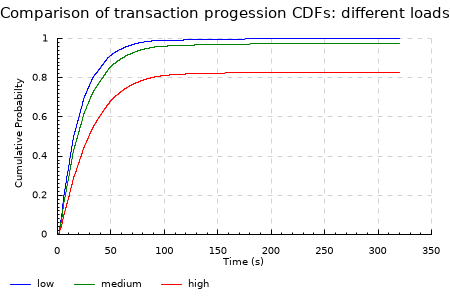

In [ ]:
toRenderable $ plotCDFs "Comparison of transaction progession CDFs: different loads"
  [ ("low",txProgression low)     -- 10%
  , ("medium",txProgression med)  -- 50%
  , ("high",txProgression hgh)    -- 90% 
  ]

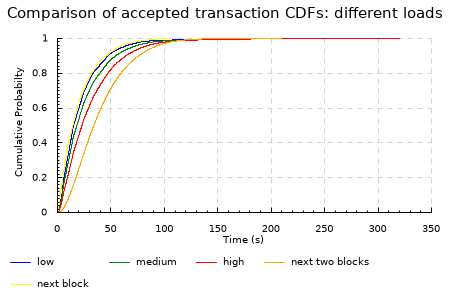

In [ ]:
-- txAccepted (pBlock,pLower)

toRenderable $ plotCDFs "Comparison of accepted transaction CDFs: different loads"
  [ ("low",txAccepted low)    -- 10%
  , ("medium",txAccepted med) -- 50%
  , ("high",txAccepted hgh)   -- 90%
  , ("next two blocks", nextBlock .>>. nextBlock)
  , ("next block", nextBlock)
  ]
  